# EDA K Nearest Neighbours

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
import pickle

## Definición del problema

>### Clasificador de Vinos con KNN
>Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas. ¿Podría una IA ayudarte a elegir un vino digno de sommelier?

## Recopilación de datos

In [46]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/raw/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Análisis Descriptivo

In [47]:
df.shape

(1599, 12)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [49]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [50]:
df.nunique()

fixed acidity            96
volatile acidity        143
citric acid              80
residual sugar           91
chlorides               153
free sulfur dioxide      60
total sulfur dioxide    144
density                 436
pH                       89
sulphates                96
alcohol                  65
quality                   6
dtype: int64

## Limpieza de datos

### Eliminar duplicados

In [51]:
df.duplicated().sum()

np.int64(240)

>Vemos 240 duplicados, los eliminaremos en la proxima celda de código

In [52]:
df.drop_duplicates(inplace=True)
df.shape

(1359, 12)

>Como vemos, se ha reducido el tamaño del DataFrame

### Eliminar información irrelevante

>A priori no vemos ningun dato irrelevante

## Análisis de Variables

### Análisis de Variables Univariante

array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

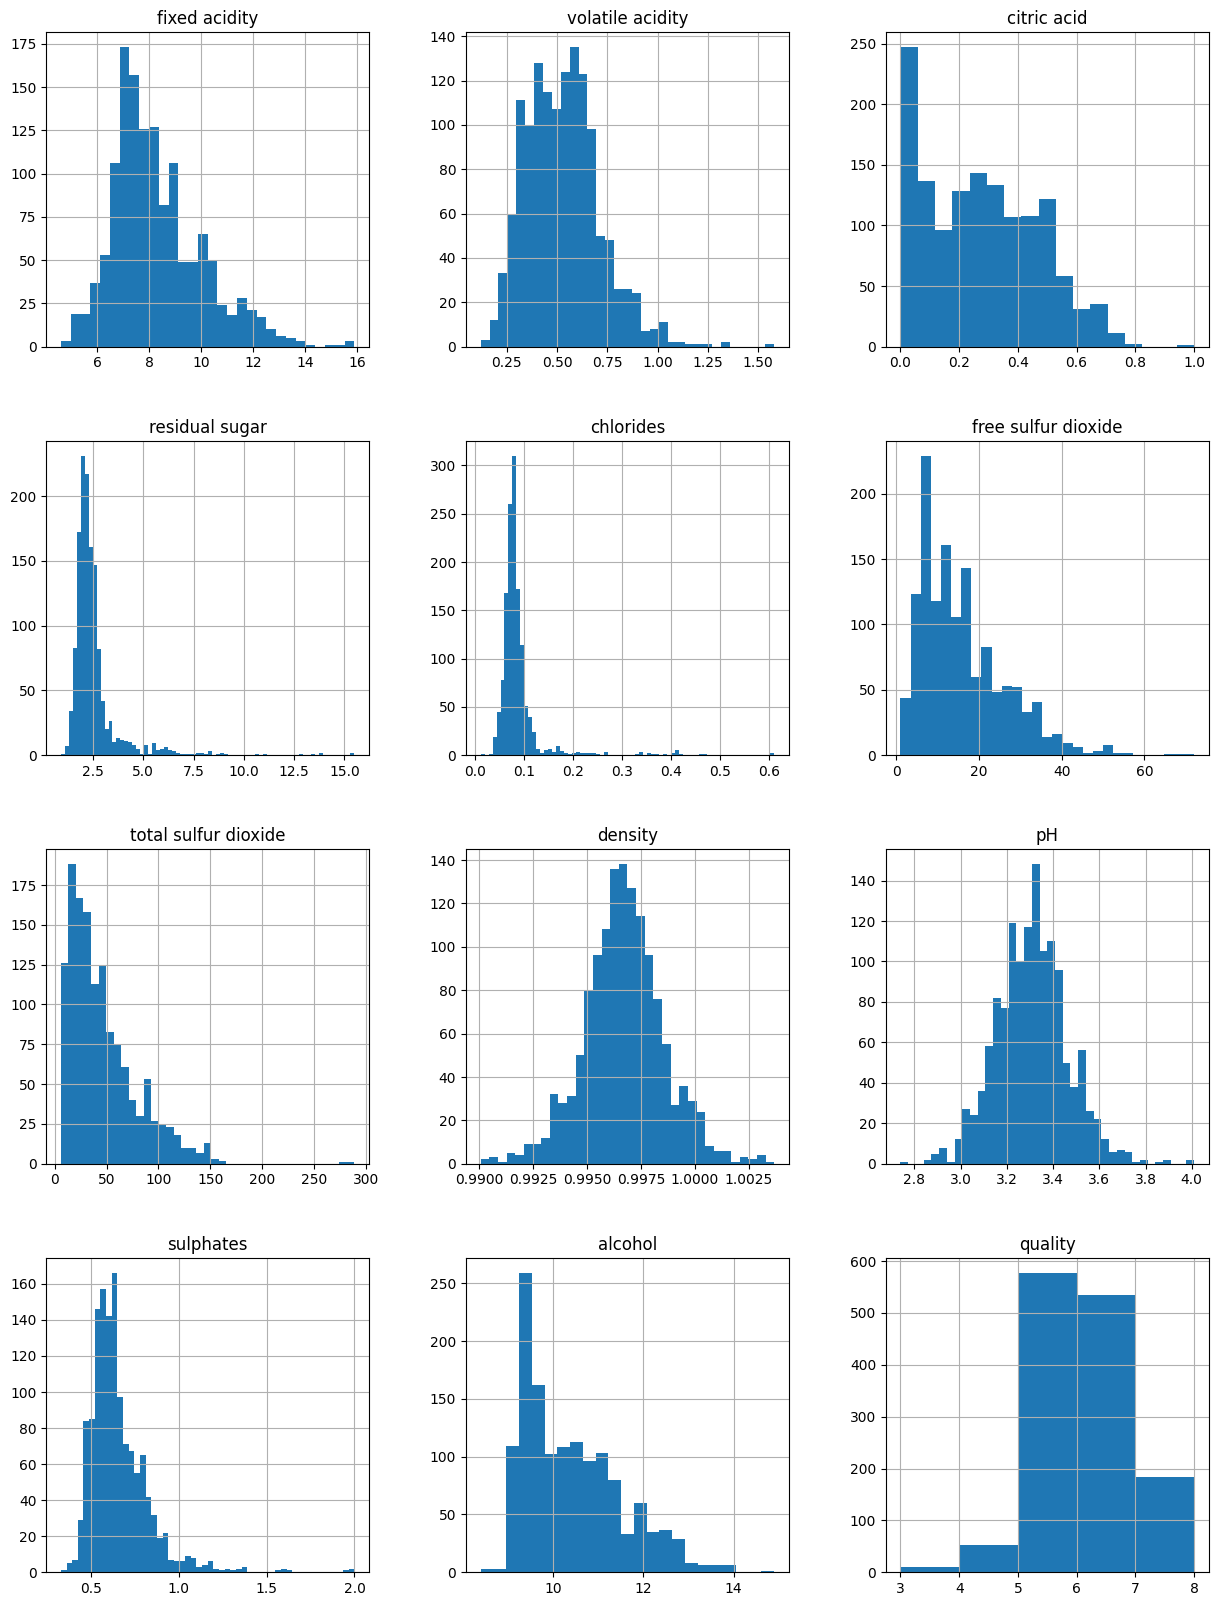

In [53]:
df.hist(figsize=[15, 20], bins='auto')

>Vemos la distribución de los datos

<function matplotlib.pyplot.show(close=None, block=None)>

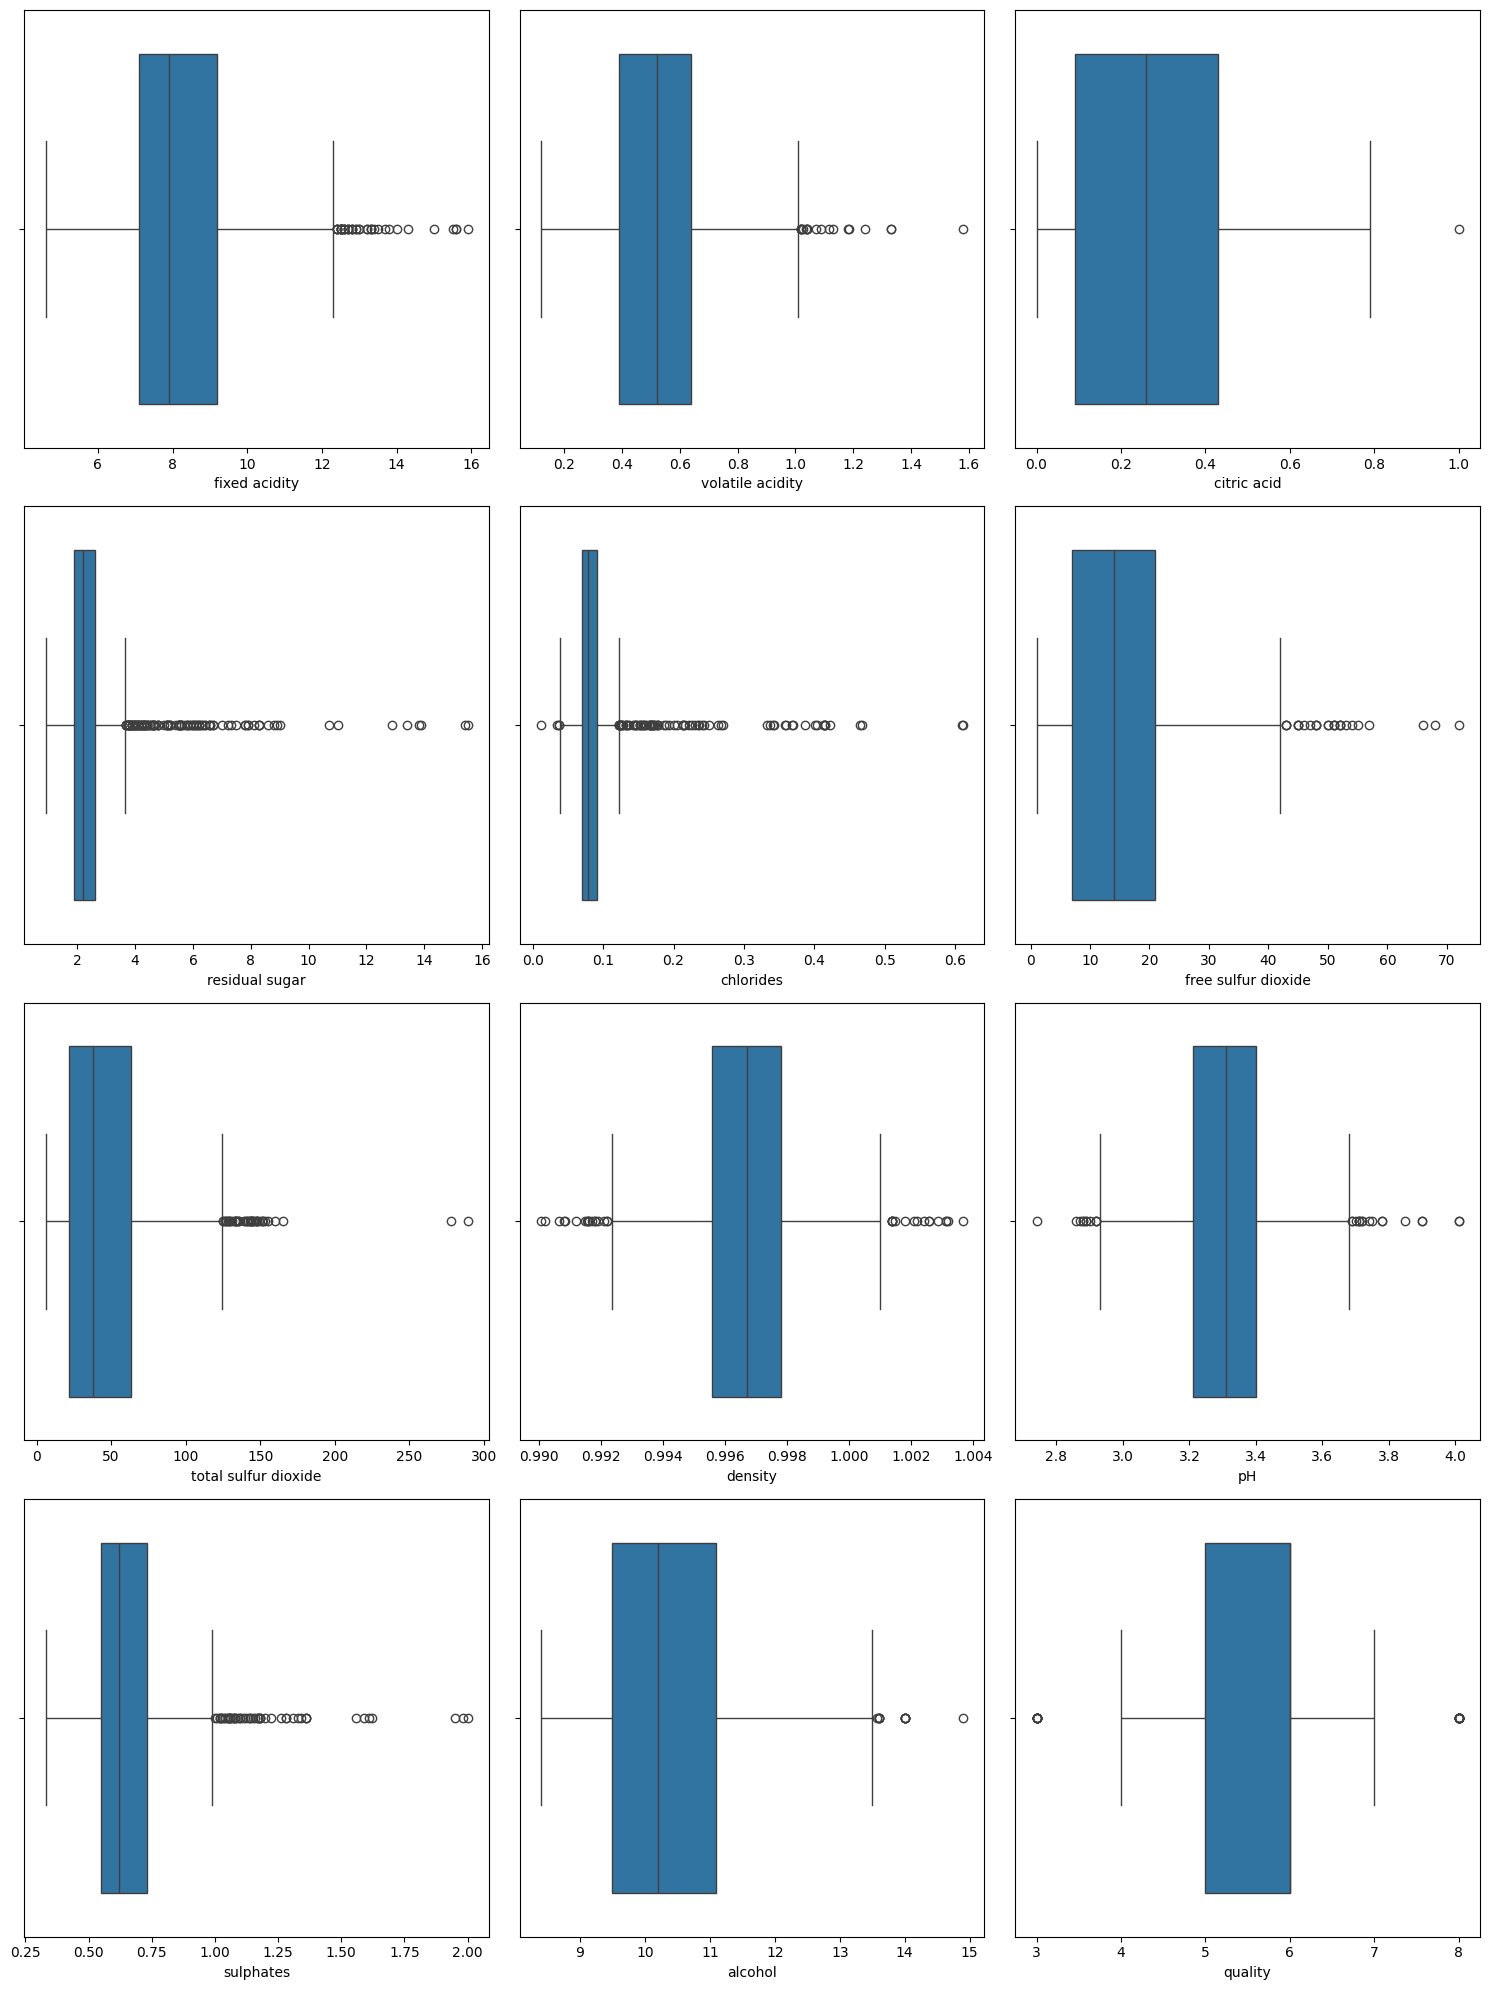

In [54]:
fig, axis = plt.subplots(4, 3, figsize=(15,20))

sns.boxplot(ax=axis[0, 0], data=df, x="fixed acidity")
sns.boxplot(ax=axis[0, 1], data=df, x="volatile acidity")
sns.boxplot(ax=axis[0, 2], data=df, x="citric acid")
sns.boxplot(ax=axis[1, 0], data=df, x="residual sugar")
sns.boxplot(ax=axis[1, 1], data=df, x="chlorides")
sns.boxplot(ax=axis[1, 2], data=df, x="free sulfur dioxide")
sns.boxplot(ax=axis[2, 0], data=df, x="total sulfur dioxide")
sns.boxplot(ax=axis[2, 1], data=df, x="density")
sns.boxplot(ax=axis[2, 2], data=df, x="pH")
sns.boxplot(ax=axis[3, 0], data=df, x="sulphates")
sns.boxplot(ax=axis[3, 1], data=df, x="alcohol")
sns.boxplot(ax=axis[3, 2], data=df, x="quality")


plt.tight_layout()
plt.show

>Vemos como estan organizados los datos y sus valores extremos o Outliers

### Análisis de Variables Multivariante

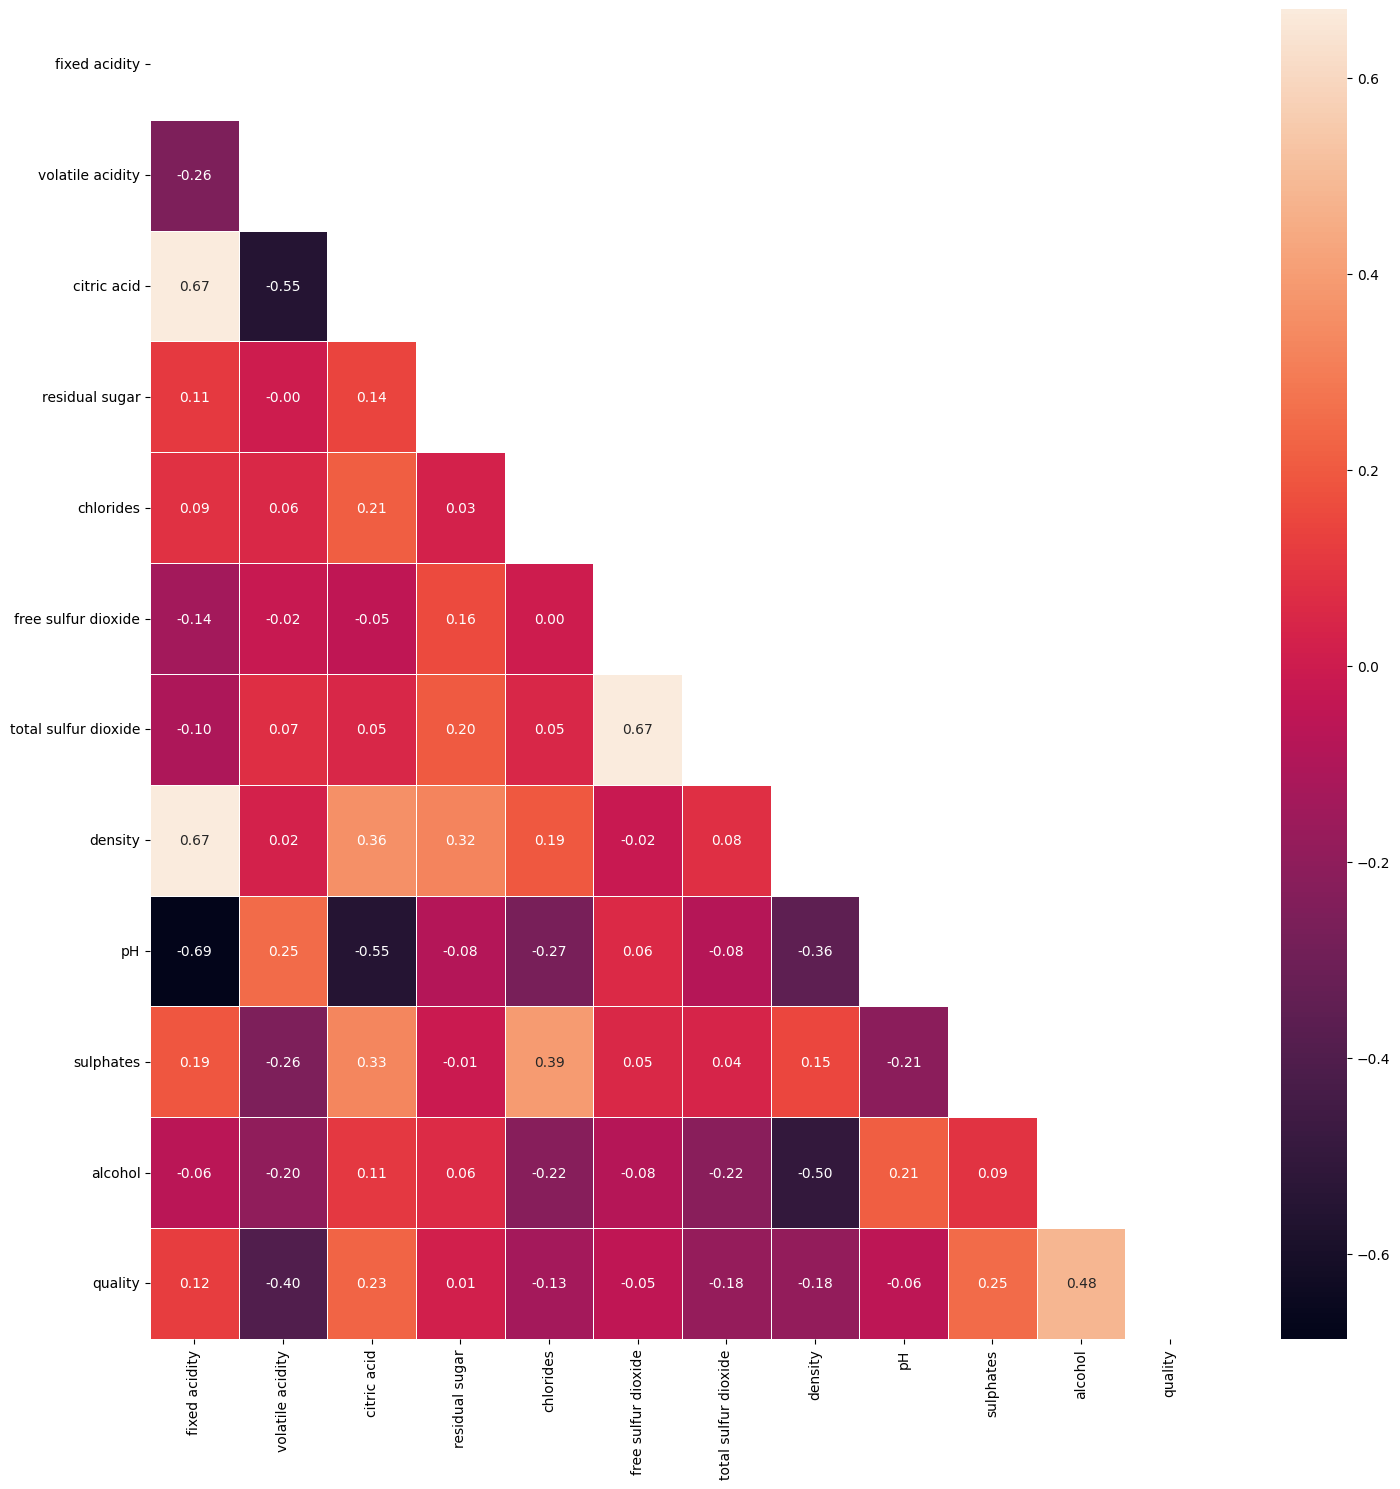

In [56]:
corr = df[['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 15))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

>Vemos una fuerte correlación con la variable objetivo de el alcohol y la acidez volatil (volatile acidity), seguida de una leve correlación con los sulfatos.

## Ingeniería de Caracteristicas

### Outliers

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1359.0,8.310596,1.736990,4.60000,7.1000,7.9000,9.20000,15.90000
volatile acidity,1359.0,0.529478,0.183031,0.12000,0.3900,0.5200,0.64000,1.58000
citric acid,1359.0,0.272333,0.195537,0.00000,0.0900,0.2600,0.43000,1.00000
residual sugar,1359.0,2.523400,1.352314,0.90000,1.9000,2.2000,2.60000,15.50000
chlorides,1359.0,0.088124,0.049377,0.01200,0.0700,0.0790,0.09100,0.61100
free sulfur dioxide,1359.0,15.893304,10.447270,1.00000,7.0000,14.0000,21.00000,72.00000
total sulfur dioxide,1359.0,46.825975,33.408946,6.00000,22.0000,38.0000,63.00000,289.00000
density,1359.0,0.996709,0.001869,0.99007,0.9956,0.9967,0.99782,1.00369
pH,1359.0,3.309787,0.155036,2.74000,3.2100,3.3100,3.40000,4.01000
sulphates,1359.0,0.658705,0.170667,0.33000,0.5500,0.6200,0.73000,2.00000


<function matplotlib.pyplot.show(close=None, block=None)>

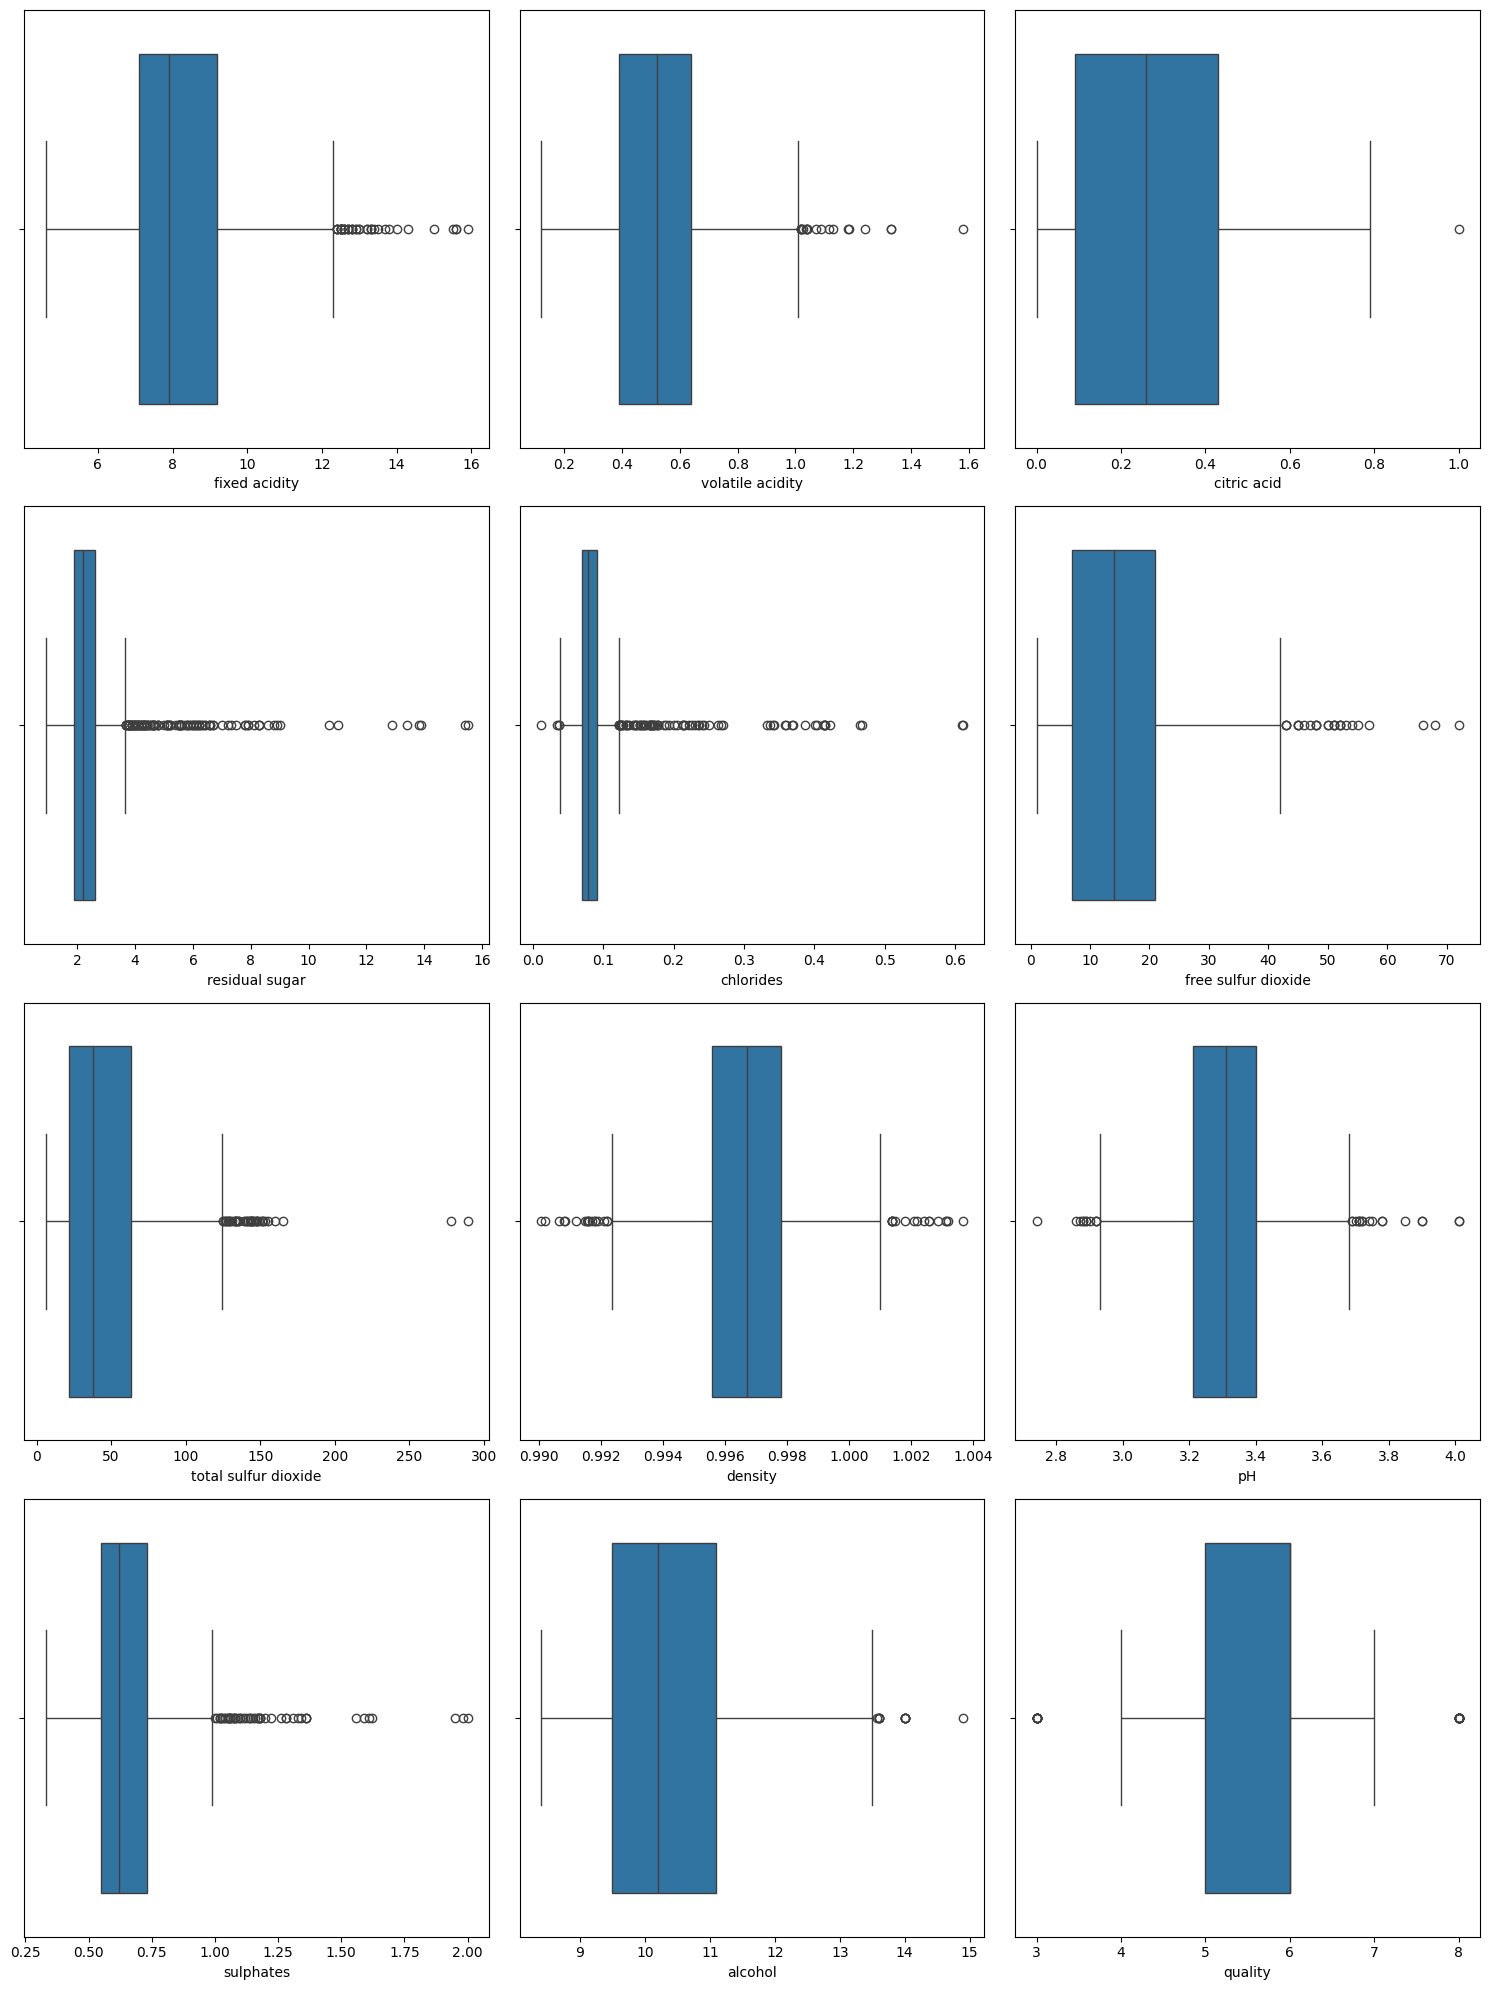

In [58]:
fig, axis = plt.subplots(4, 3, figsize=(15,20))

sns.boxplot(ax=axis[0, 0], data=df, x="fixed acidity")
sns.boxplot(ax=axis[0, 1], data=df, x="volatile acidity")
sns.boxplot(ax=axis[0, 2], data=df, x="citric acid")
sns.boxplot(ax=axis[1, 0], data=df, x="residual sugar")
sns.boxplot(ax=axis[1, 1], data=df, x="chlorides")
sns.boxplot(ax=axis[1, 2], data=df, x="free sulfur dioxide")
sns.boxplot(ax=axis[2, 0], data=df, x="total sulfur dioxide")
sns.boxplot(ax=axis[2, 1], data=df, x="density")
sns.boxplot(ax=axis[2, 2], data=df, x="pH")
sns.boxplot(ax=axis[3, 0], data=df, x="sulphates")
sns.boxplot(ax=axis[3, 1], data=df, x="alcohol")
sns.boxplot(ax=axis[3, 2], data=df, x="quality")


plt.tight_layout()
plt.show

>Todas las variables contienen outliers, pero vemos valores mucho más extremos que en las otras en residual sugar y chlorides sobretodo aunque también son destacables los de fixed acidity, volatile acidity, free sulfur dioxide, total sulfur dioxide y sulphates, sobretodo porque estos caen hacia solo el lado positivo. 

>No los trataremos porque nos importan los extremos también para evaluar la calidad del vino

### Faltantes

In [59]:
df.isnull().sum().sort_values(ascending=False)

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

>No hay valores faltantes en ninguna columna

### Inferencia de nuevas características

>Ya que el ejercicio nos pide que la columna objetivo sea "label" y esa esté diferenciada en tres posibles salidas voy a transformar la columna quality en esta creando una nueva que a los valores 3 y 4 de quality los transforme en 0 de label (Baja calidad), los valores 5 y 6 de quality se transformarán en 1 de label (Calidad media) y los valores 7 y 8 de quality serán el valor 2 de label (Alta calidad). Después de crear la nueva variable objetivo eliminaré la anterior quality para que no afecte en el modelado ya que se podría predecir label muy facilmente a partir de esta.

In [60]:
df['label'] = pd.cut(df['quality'], bins=[2, 4, 6, 8], 
                     labels = [0, 1, 2])
df['label'] = df['label'].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1359 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1359 non-null   float64
 1   volatile acidity      1359 non-null   float64
 2   citric acid           1359 non-null   float64
 3   residual sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free sulfur dioxide   1359 non-null   float64
 6   total sulfur dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
 12  label                 1359 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 148.6 KB


In [61]:
df.drop(['quality'], axis=1, inplace=True)
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,1
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,1
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,1
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,1
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,1
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,1


## Split

In [ ]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=25)

## Scaling & Encoding

### Scaling

>Utilizaré robust scaler para escalar los datos ya que encontramos outliers en todas las columnas y este es el escalador que mejor los trata

In [63]:
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(X_train)
robust_scaler_test = robust_scaler.transform(X_test)

X_train = pd.DataFrame(robust_scaler_train, 
                             columns=X_train.columns,
                             index=X_train.index)

X_test = pd.DataFrame(robust_scaler_test, 
                            columns=X_test.columns,
                            index=X_test.index)

X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1404,0.047619,-0.083333,0.382353,0.571429,0.142857,-0.071429,0.214286,0.818182,0.631579,0.000000,0.3125
1198,-0.095238,-1.083333,0.000000,-0.285714,-1.285714,0.428571,0.952381,-0.727273,-0.842105,0.944444,0.4375
769,0.000000,0.833333,-0.735294,-0.428571,-0.142857,-0.428571,-0.119048,-0.009091,0.421053,-0.444444,-0.3750
379,0.190476,-0.416667,0.352941,0.428571,0.714286,0.785714,0.547619,0.545455,0.000000,0.444444,0.3750
63,-0.428571,0.895833,-0.617647,-0.285714,0.095238,0.000000,0.404762,-0.045455,0.421053,-0.277778,-0.2500


### Encoding

>No hace falta hacer encoding ya que todos los datos son numéricos

### Guardado de Scalings y Encodings

In [64]:
with open('/workspaces/adamcn10-intro-ml/models/knn-robust-scaler.pkl', 'wb') as file:
    pickle.dump(robust_scaler, file)  

## Guardado de datos procesados

In [66]:
X_train.to_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-X-train.csv')
X_test.to_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-X-test.csv')
y_train.to_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-y-train.csv')
y_test.to_csv('/workspaces/adamcn10-intro-ml/data/processed/knn-y-test.csv')